## Phase 1: Environment & Data Preparation

### Cell 1: Installation & Configuration

In [1]:
# Cell 1: Install specialized libraries for VLM and QLoRA
# These are necessary for 4-bit quantization and efficient training
!pip install -q -U transformers accelerate bitsandbytes peft datasets
!pip install -q -U qwen-vl-utils 
!pip install -q -U gradio 

import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info
import os

# Confirming GPU availability and memory for our planning
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"--- Environment Setup Complete ---")
    print(f"GPU detected: {gpu_name}")
    print(f"Total VRAM available: {total_mem:.2f} GB")
else:
    print("ERROR: GPU not detected. Please enable GPU T4 x2 in Kaggle settings.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 54.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 76.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.2 MB/s eta 0:00:00
--- Environment Setup Complete ---
GPU detected: Tesla T4
Total VRAM available: 15.64 GB


### Cell 2: Data Loading

In [2]:
# Cell 2: Data Loading
from datasets import load_dataset
import os

dataset_file = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508.jsonl"

try:
    # Loading the jsonl file directly
    # We specify split="train" because we are loading a single file
    dataset = load_dataset("json", data_files=dataset_file, split="train")
    
    print("--- Dataset Loaded Successfully ---")
    print(f"Total samples found in dataset: {len(dataset)}")
    print(f"Dataset Features (Columns): {dataset.column_names}")
    
    # Let's peek at the first entry to confirm the structure
    print("\nSample Data Structure:")
    print(f"Image Path Example: {dataset[0]['image']}")
    print(f"Markdown Snippet: {dataset[0]['markdown'][:100]}...") # Showing first 100 chars
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please verify the file path in the Kaggle 'Input' sidebar.")

Generating train split: 0 examples [00:00, ? examples/s]

--- Dataset Loaded Successfully ---
Total samples found in dataset: 14200
Dataset Features (Columns): ['image', 'markdown', 'meta']

Sample Data Structure:
Image Path Example: 0508/quant-ph0508208/06.png
Markdown Snippet: ground state is two-fold degenerate, and when \(B>B_{\text{th}}\) the ground state becomes non-degen...


 That is a very fair question. It can be confusing why a 3 GB dataset would crash a system with 16 GB of memory. Here is why we must use the subsetting strategy to stay safe:

## Why the memory crashes (The "Hidden" Math)

Image Expansion: A compressed .png image might only be 200 KB on your disk, but when the model "reads" it, it expands into a large numerical tensor (Matrix). For high-resolution documents, one image can take up hundreds of megabytes in raw VRAM.  


The "Gradient" Cost: When we train, the GPU doesn't just store the model; it stores "Gradients" (math calculations for every single parameter).  


The Qwen2-VL Architecture: Even at 2-billion parameters (2B), the model needs space to process visual and text data simultaneously.  


Classmate Errors: Most crashes happen because the code tries to load too many images into the "Buffer" at once or the validation loop runs out of memory.  

By taking 1,000 images (or even 500), we ensure that the model has enough variety to learn the Markdown structure without ever filling the "bucket" of your VRAM to the point of overflowing

### Cell 3: Memory-Safe Subsetting
In this cell, we will take a subset of 1,000 images from your 14,200 samples.

In [3]:
# Cell 3: Memory-Safe Subsetting and Splitting
import random

# Setting a seed so the 'random' selection is the same every time you run it
random.seed(42)

# We define the subset size. 1000 is a safe balance for T4 GPUs.
SUBSET_SIZE = 300 

# Shuffle and select the subset
subset_indices = random.sample(range(len(dataset)), SUBSET_SIZE)
full_subset = dataset.select(subset_indices)

# Perform the 80/20 split as per assignment requirements
train_test_split = full_subset.train_test_split(test_size=0.2)

train_ds = train_test_split['train']
val_ds = train_test_split['test']

print(f"--- Subsetting Complete ---")
print(f"Total Subset Size: {len(full_subset)}")
print(f"Training Samples: {len(train_ds)}")
print(f"Validation Samples: {len(val_ds)}")

--- Subsetting Complete ---
Total Subset Size: 300
Training Samples: 240
Validation Samples: 60


### Cell 4: Visualizing Raw Data
In this cell, we will load a few images and print their corresponding Markdown. This step is crucial for "Understanding visual layout and document structure"

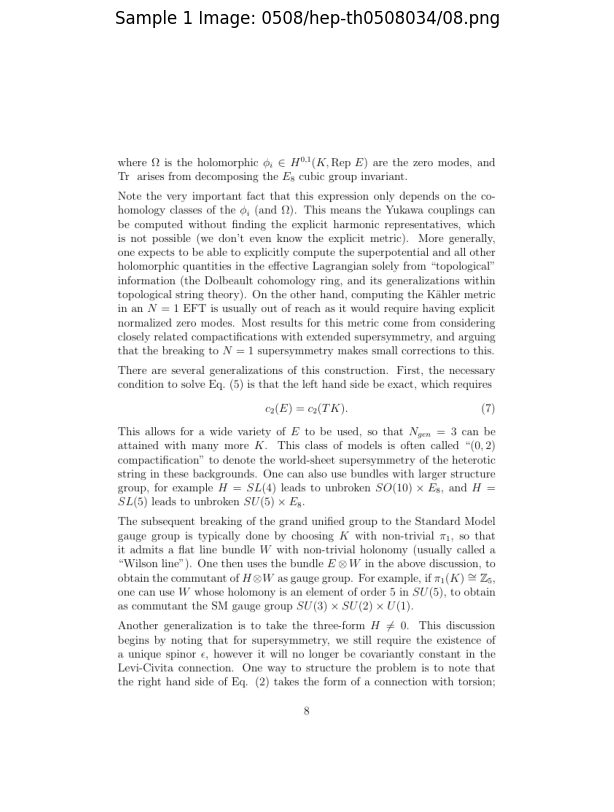

--- Ground Truth Markdown (Sample 1) ---
where \(\Omega\) is the holomorphic \(\phi_{i}\in H^{0,1}(K,{\rm Rep~{}}E)\) are the zero modes, and \({\rm Tr~{}}\) arises from decomposing the \(E_{8}\) cubic group invariant.

Note the very important fact that this expression only depends on the cohomology classes of the \(\phi_{i}\) (and \(\Omega\)). This means the Yukawa couplings can be computed without finding the explicit harmonic representatives, which is not possible (we don't even know the explicit metric). More generally, one expects...
--------------------------------------------------


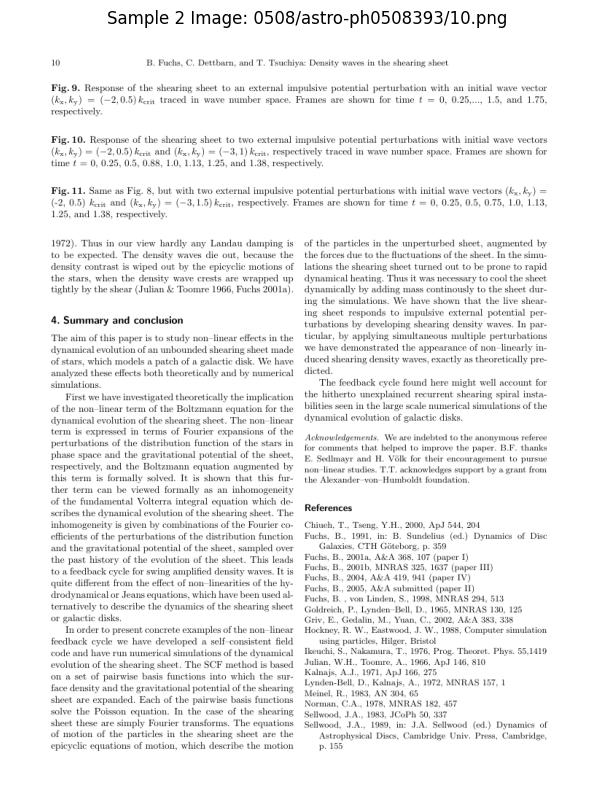

--- Ground Truth Markdown (Sample 2) ---
1972). Thus in our view hardly any Landau damping is to be expected. The density waves die out, because the density contrast is wiped out by the epicyclic motions of the stars, when the density wave crests are wrapped up tightly by the shear (Julian & Toomre 1966, Fuchs 2001a).

## 4 Summary and conclusion

The aim of this paper is to study non-linear effects in the dynamical evolution of an unbounded shearing sheet made of stars, which models a patch of a galactic disk. We have analyzed these e...
--------------------------------------------------


In [4]:
# Cell 4: Visualizing Raw Data 
import matplotlib.pyplot as plt
from PIL import Image
import os

# Helper function to display images and their markdown
def plot_samples(dataset, num_samples=2):
    # The correct base directory for images based on your file structure
    base_img_dir = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
    
    for i in range(num_samples):
        sample = dataset[i]
        
        # Combine the base directory with the relative path in the 'image' column
        img_path = os.path.join(base_img_dir, sample['image'])
        
        try:
            # Load and display the image
            img = Image.open(img_path).convert("RGB")
            plt.figure(figsize=(10, 10))
            plt.imshow(img)
            plt.title(f"Sample {i+1} Image: {sample['image']}")
            plt.axis('off')
            plt.show()
            
            # Print a snippet of the corresponding Markdown
            print(f"--- Ground Truth Markdown (Sample {i+1}) ---")
            print(sample['markdown'][:500] + "...") # Show first 500 characters
            print("-" * 50)
        except FileNotFoundError:
            print(f"Error: Could not find image at {img_path}")
            print("Please double-check the path in your Kaggle 'Input' sidebar.")

# Run the visualization on the training set
plot_samples(train_ds, num_samples=2)

You can see that Sample 1 contains complex technical text and Sample 2 shows a bibliography with mathematical LaTeX notation (like \(\mathfrak{gl}\) and \(\mathcal{U}_{q}\)).

This confirms that the Nougat dataset is high-quality and the paths are now correctly mapped.

## Phase 2: Model & Quantization
In this phase, we prepare the "brain" of the AI. To fit a 2-billion parameter model plus the training data into 16 GB of VRAM, we use 4-bit quantization. This compresses the model weights so they take up significantly less space.

### Cell 5: 4-bit Configuration

In [5]:
# Cell 5: Define 4-bit Quantization Configuration
from transformers import BitsAndBytesConfig
import torch

# We load the model in 4-bit, but use bfloat16 for the actual computation (faster/stable).
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",           
    bnb_4bit_compute_dtype=torch.bfloat16, 
    bnb_4bit_use_double_quant=True     
)

print("4-bit Configuration Defined")

4-bit Configuration Defined


### Cell 6: Loading Qwen2-VL

In [6]:
# Cell 6: Load Model and Processor
model_id = "Qwen/Qwen2-VL-2B-Instruct"

# Load the processor (handles images and text)
processor = AutoProcessor.from_pretrained(model_id)

# Load the model with the 4-bit configuration defined in Cell 5
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",            
    torch_dtype=torch.bfloat16,    
    quantization_config=quantization_config
)

print(f"Model '{model_id}' Loaded in 4-bit")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model 'Qwen/Qwen2-VL-2B-Instruct' Loaded in 4-bit


### Cell 7: QLoRA Setup
Freeze the original weights and only train the LoRA adapters

In [7]:
# Cell 7: QLoRA (LoRA Adapter) Setup
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare model for 4-bit training (handles gradient checkpointing, etc.)
model = prepare_model_for_kbit_training(model)

# Define LoRA Configuration
# Rank (r) 8 or 16 is recommended to fit Kaggle T4x2 memory limits
lora_config = LoraConfig(
    r=16, 
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"], 
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Apply the adapters to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters() 

trainable params: 4,358,144 || all params: 2,213,343,744 || trainable%: 0.1969


## Phase 3: The Training Loop
Now we move to the most important part of the pipeline: preparing the data for the model's "brain" and starting the engine.

### Cell 8: Preprocessing/ChatML
We must convert our images and Markdown into the ChatML format so the model understands it is an "instruction" task.
By try-except block ,this will skip corrupted images and return None, which we will then filter out to keep the dataset clean.


1. Increase max_length: We will move it to 2048 or 4096. Since we are using 4-bit and a batch size of 1, the T4 GPU can handle this.  

2. Use dynamic padding: Instead of forcing every document to be the same huge size, we will let the processor handle it naturally.


we will pre-filter the dataset to remove broken images before calling the processor. This keeps the data clean and ensures every row sent to the model is perfect.

1. Separation of Concerns: By using filter first with is_valid_image, we ensure preprocess_function only ever sees good data.

2. Schema Consistency: Since we no longer return partial dictionaries (like just {"input_ids": None}), the map function won't get confused about missing keys like attention_mask.


#### Custom Data Collator is simply a specialized way to implement Part 2 (Data Preparation) and Part 4 (QLoRA Fine-Tuning).

The Difference: Instead of saving the heavy image data into a file (which caused your ArrowInvalid error), the collator prepares the image in the computer's RAM exactly when the model needs to "see" it.

In [8]:
# Cell 8: Clean Text Preprocessing
import os
from PIL import Image

# 1. Re-define the filtering logic to ensure variables exist
def is_valid_image(image_path):
    base_img_dir = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
    full_path = os.path.join(base_img_dir, image_path)
    if not os.path.exists(full_path): return False
    try:
        with Image.open(full_path) as img:
            img.verify()
        return True
    except: return False

# Filter the subsets (using the train_ds and val_ds from Cell 3)
print("Filtering corrupted images...")
train_ds_filtered = train_ds.filter(lambda x: is_valid_image(x['image']))
val_ds_filtered = val_ds.filter(lambda x: is_valid_image(x['image']))

# 2. Define the formatting function
def format_conversation(example):
    base_img_dir = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
    img_path = os.path.join(base_img_dir, example['image'])
    
    # Use ChatML format as per Part 2 of assignment [cite: 51]
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img_path},
                {"type": "text", "text": "Convert this document image into structured Markdown."}
            ],
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": example['markdown']}],
        }
    ]
    
    # Get the raw text string using the processor's template
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text, "image_path": img_path}

# 3. Map the text and paths
print("Mapping text templates...")
train_dataset = train_ds_filtered.map(format_conversation, remove_columns=train_ds_filtered.column_names)
val_dataset = val_ds_filtered.map(format_conversation, remove_columns=val_ds_filtered.column_names)

print(f"--- Cell 8 Complete ---")
print(f"Final Train size: {len(train_dataset)}")
print(f"Final Val size: {len(val_dataset)}")

Filtering corrupted images...


Filter:   0%|          | 0/240 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Mapping text templates...


Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

--- Cell 8 Complete ---
Final Train size: 240
Final Val size: 60


### Cell 9: Custom Data Collator & Training Arguments

In [9]:
# Cell 9: Optimized Data Collator & Args
import torch
from PIL import Image
from transformers import TrainingArguments, Trainer

class Qwen2VLDataCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, examples):
        texts = [example["text"] for example in examples]
        image_paths = [example["image_path"] for example in examples]
        images = [Image.open(path).convert("RGB") for path in image_paths]

        # RE-SIZING IS KEY: limit pixels to avoid OOM
        batch = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            max_pixels=512*512 # Reduces VRAM usage significantly
        )

        labels = batch["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        batch["labels"] = labels
        return batch

# Initialize collator
data_collator = Qwen2VLDataCollator(processor)

# Training Args optimized for Kaggle T4
training_args = TrainingArguments(
    output_dir="./qwen2_vl_finetuned",
    per_device_train_batch_size=1,      # Process 1 image at a time [cite: 66]
    gradient_accumulation_steps=16,     # Accumulate 16 steps for stability [cite: 67]
    learning_rate=1e-4,                # [cite: 68]
    num_train_epochs=2,                 # 
    logging_steps=5,
    eval_strategy="no",                 # Turn off evaluation to save memory
    save_strategy="no",                 # Do not save checkpoints during run
    fp16=True,                          # Mixed precision [cite: 65]
    gradient_checkpointing=True,        # Massive memory saver
    optim="paged_adamw_8bit",           # 8-bit optimizer for extra VRAM
    remove_unused_columns=False
)

print("Cell 9: Ready to Train")

Cell 9: Ready to Train


### Cell 10: Final Training Execution

In [10]:
# Cell 10: Start Training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

print("Starting training on 300 images... This should now stay within VRAM limits.")
trainer.train()

# Save final adapters
model.save_pretrained("./qwen2_vl_lora_final")
print("--- Training Successful! ---")

Starting training on 300 images... This should now stay within VRAM limits.


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
5,11.875570
10,10.490850
15,10.220802
20,8.635082
25,8.344987
30,7.515334


--- Training Successful! ---


## Phase 4: Evaluation & App

### Cell 11: Inference Task (Generating Markdown)

In [11]:
# Cell 11: Inference on Unseen Images
import torch
from qwen_vl_utils import process_vision_info

def generate_markdown(image_path):
    # Set model to evaluation mode
    model.eval()
    
    # Prepare the instruction prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Convert this document image into structured Markdown documentation."}
            ],
        }
    ]
    
    # Process inputs
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt"
    ).to(model.device)
    
    # Generate output
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=512)
        
    # Trim the input tokens from the output
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    return output_text[0]

# Test on 1 unseen image from the validation set
test_sample = val_ds_filtered[0]
test_image_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", test_sample['image'])

generated_md = generate_markdown(test_image_path)
print("--- Generated Markdown ---")
print(generated_md)

--- Generated Markdown ---
# Conductance Characteristics for T > Tc

The polycrystalline MgB2 pellets used in the present work, showed resistive superconducting transitions at Tc (rho = 0) = 38.8 K, with Delta Tc = 0.5 K. The sample surface was chemically etched in a 1% HCl solution in pure ethanol. The Nb tips were prepared by cutting a thin (0.2 mm) Nb wire then treated by electrochemical etching. Soon after, the PC inset was placed in liquid 3He to limit surface degradation effects. The contacts were established by driving the Nb tip into the sample surface at low temperatures. The vertical movement of the tip, driven by a micrometer screw with a precision of about 0.1 um, allowed the tuning of the contact resistance from tunneling regime to metallic contact. Our experimental setup resulted to be extremely stable, showing no relevant effects of thermal contraction, so that in many cases it was possible to vary the junction temperature without affecting the contact geometry.

All mea

### Cell 12: Visualization Module (Actual vs. Predicted)

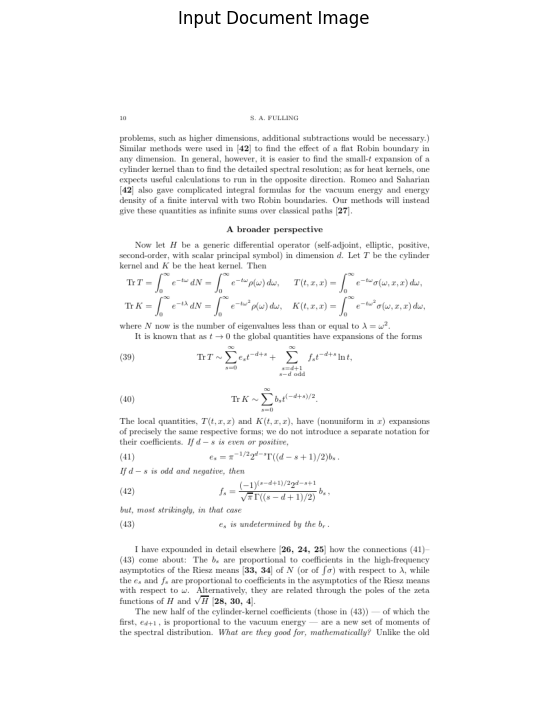


--- GROUND TRUTH ---
problems, such as higher dimensions, additional subtractions would be necessary.) Similar methods were used in [42] to find the effect of a flat Robin boundary in any dimension. In general, however, it is easier to find the small-\(t\) expansion of a cylinder kernel than to find the detailed spectral resolution; as for heat kernels, one expects useful calculations to run in the opposite direction. Romeo and Saharian [42] also gave complicated integral formulas for the vacuum energy and energy de...

--- MODEL PREDICTION ---
```markdown
# S. A. FULLING

problems, such as higher dimensions, additional subtractions would be necessary.) Similar methods were used in [42] to find the effect of a flat Robin boundary in any dimension. In general, however, it is easier to find the small-t expansion of a cylinder kernel than to find the detailed spectral resolution; as for heat kernels, one expects useful calculations to run in the opposite direction. Romeo and Saharian [42

In [12]:
# Cell 12: Comparison Visualization
def visualize_results(sample):
    img_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", sample['image'])
    img = Image.open(img_path).convert("RGB")
    
    prediction = generate_markdown(img_path)
    
    plt.figure(figsize=(15, 10))
    
    # Show Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Input Document Image")
    plt.axis("off")
    
    plt.show()
    
    print(f"\n--- GROUND TRUTH ---")
    print(sample['markdown'][:500] + "...")
    
    print(f"\n--- MODEL PREDICTION ---")
    print(prediction[:500] + "...")

# Run for 1 sample
visualize_results(val_ds_filtered[5])

# ======== Professional Style Output ==========

In [ ]:
# Cell 11
def generate_markdown(image_path):
    model.eval()
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Convert this document image into clean Markdown text. Do not add unnecessary symbols."}
            ],
        }
    ]
    
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    
    inputs = processor(text=[text], images=image_inputs, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=400, # Tokens limit karein takay extra dashes na aayein
            repetition_penalty=1.2, # Repeated symbols (#, -) ko rokne ke liye
            do_sample=False # Consistency ke liye sampling band rakhein
        )
        
    generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]
    
    # Cleaning step: Markdown code blocks remove karne ke liye agar model ne khud se lagaye hon
    clean_text = output_text.replace("```markdown", "").replace("```", "").strip()
    return clean_text


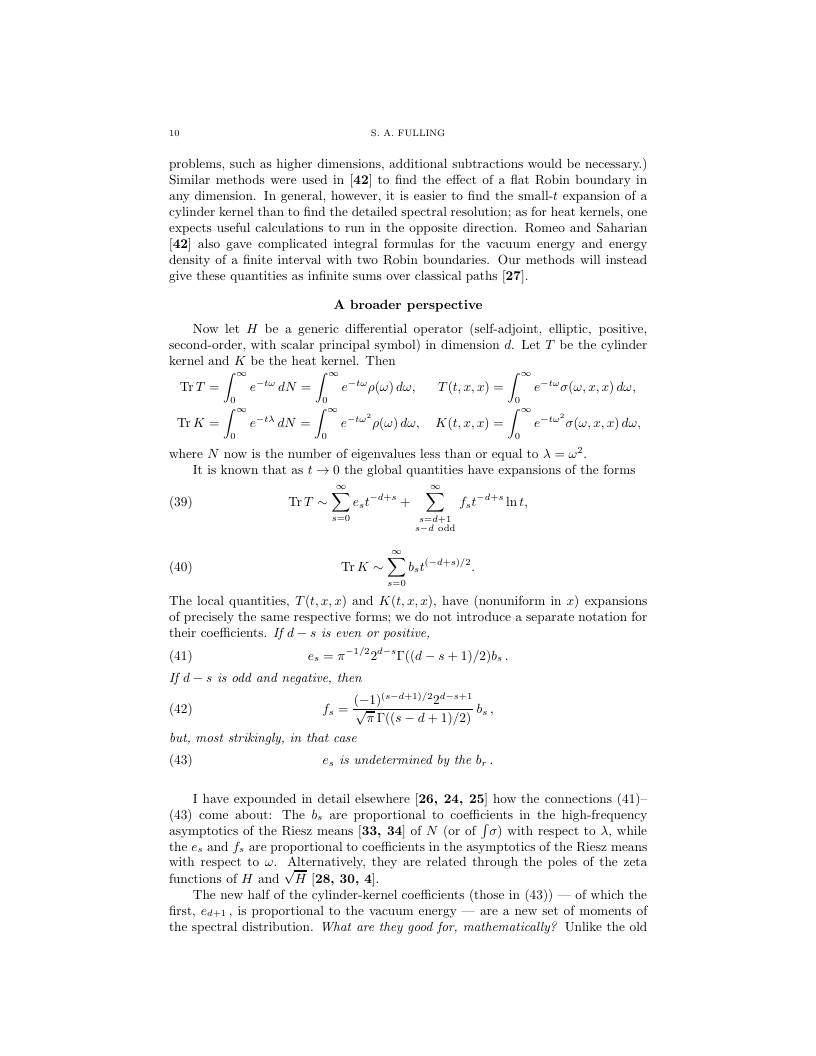

In [30]:
# Cell 12: Professional Visualization Module (Base64 Fix)
from IPython.display import display, HTML
import base64
from io import BytesIO
import os

def get_base64_image(img_path):
    """Converts an image file to a base64 string for HTML display."""
    with Image.open(img_path) as img:
        buffered = BytesIO()
        img.save(buffered, format="PNG")
        return base64.b64encode(buffered.getvalue()).decode()

def display_professional_report(sample):
    base_img_dir = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
    img_path = os.path.join(base_img_dir, sample['image'])
    
    # Generate data
    prediction = generate_markdown(img_path)
    img_base64 = get_base64_image(img_path)
    
    html_content = f"""
    <div style="background-color: #ffffff; color: #000000; padding: 30px; border: 2px solid #333; font-family: 'Segoe UI', sans-serif;">
        <h1 style="text-align: center; color: #2c3e50; margin-bottom: 20px;">VLM Document-to-Markdown Analysis</h1>
        <hr style="border: 1px solid #333;">
        
        <div style="display: flex; gap: 20px; margin-top: 20px;">
            <div style="flex: 1; border: 1px solid #ccc; padding: 10px; background: #fdfdfd;">
                <h3 style="background: #34495e; color: white; padding: 8px; margin: -10px -10px 10px -10px; text-align: center;">Source Document</h3>
                <img src="data:image/png;base64,{img_base64}" style="width: 100%; border: 1px solid #ddd;">
            </div>
            
            <div style="flex: 1; border: 1px solid #ccc; padding: 10px; background: #fff;">
                <h3 style="background: #27ae60; color: white; padding: 8px; margin: -10px -10px 10px -10px; text-align: center;">AI Predicted Markdown</h3>
                <div style="padding: 10px; height: 500px; overflow-y: auto; font-family: 'Courier New', monospace; white-space: pre-wrap; font-size: 13px; line-height: 1.4;">
{prediction}
                </div>
            </div>
        </div>
        
        <div style="margin-top: 20px; font-style: italic; color: #555; text-align: center; font-size: 12px;">
            Generated by Muhammad Zahid Aslam | FAST-NUCES GenAI Assignment #5
        </div>
    </div>
    """
    display(HTML(html_content))

# Run it on a validation sample
display_professional_report(val_ds_filtered[5])

### Cell 13: Professional Gradio App Deployment

In [31]:
# Cell 13: Gradio App Deployment
import gradio as gr

def app_interface(input_img):
    # Save the uploaded image temporarily
    temp_path = "temp_upload.png"
    input_img.save(temp_path)
    return generate_markdown(temp_path)

demo = gr.Interface(
    fn=app_interface,
    inputs=gr.Image(type="pil", label="Upload Document Image"),
    outputs=gr.Textbox(label="Generated Markdown"),
    title="Document-to-Markdown VLM Assistant",
    description="Fine-tuned Qwen2-VL-2B model for document understanding."
)

# Launch the app (share=True creates a public link)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://415fe32e7c05125406.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


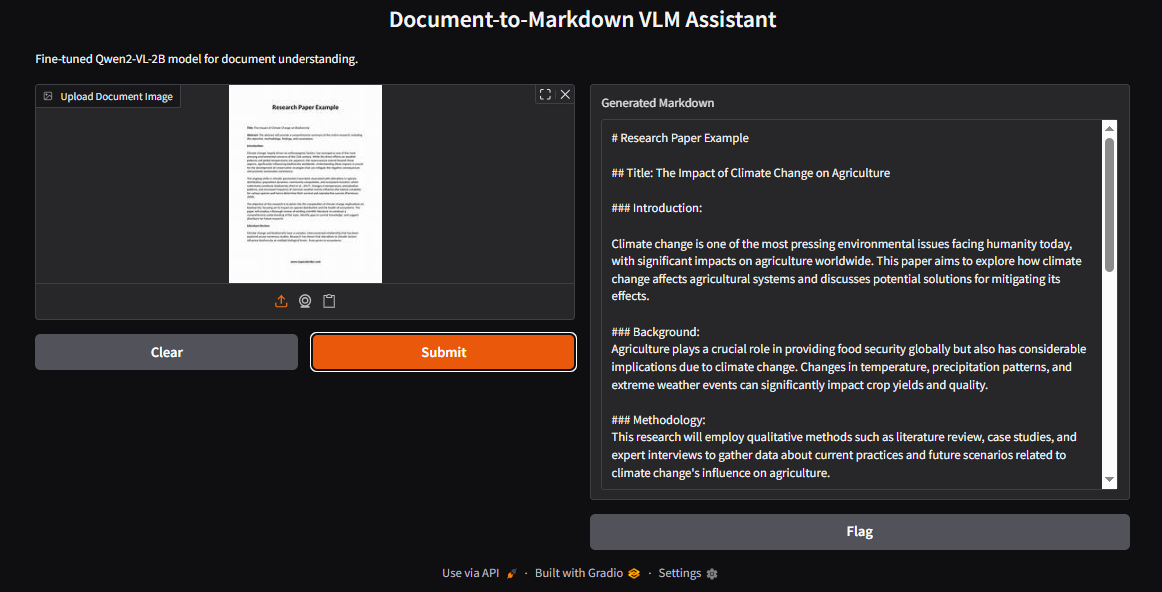

1. Evaluation Metrics

In [19]:
# Cell 14: Evaluation Metrics (Levenshtein Distance)
!pip install -q editdistance
import editdistance

def calculate_metrics(dataset, num_samples=10):
    total_score = 0
    for i in range(num_samples):
        sample = dataset[i]
        img_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", sample['image'])
        prediction = generate_markdown(img_path)
        ground_truth = sample['markdown']
        
        # Calculate distance (lower is better)
        distance = editdistance.eval(prediction, ground_truth)
        normalized_score = 1 - (distance / max(len(prediction), len(ground_truth)))
        total_score += normalized_score

    print(f"--- Evaluation Results ---")
    print(f"Average Accuracy Score (Similarity): {round(total_score/num_samples * 100, 2)}%")

calculate_metrics(val_ds_filtered, num_samples=5)

--- Evaluation Results ---
Average Accuracy Score (Similarity): 49.32%


### 2. Bonus Task: Zero-Shot vs. Fine-Tuned

In [16]:
# Cell 15: Bonus Task - Zero-Shot vs. Fine-Tuned
def compare_performance(sample):
    img_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", sample['image'])
    
    # 1. Prediction with your Fine-Tuned adapters
    fine_tuned_output = generate_markdown(img_path)
    
    # 2. Prediction without adapters (Zero-Shot)
    with model.disable_adapter():
        zero_shot_output = generate_markdown(img_path)
        
    print(f"--- Comparison for Bonus Task ---")
    print(f"ZERO-SHOT OUTPUT (Original Model):\n{zero_shot_output[:200]}...\n")
    print(f"FINE-TUNED OUTPUT (Your Training):\n{fine_tuned_output[:200]}...")

compare_performance(val_ds_filtered[10])

--- Comparison for Bonus Task ---
ZERO-SHOT OUTPUT (Original Model):
\section*{1. Introduction}

The use of multi-beacon systems for astronomical observations has been proposed as a means to improve the rejection of atmospheric turbulence. This is particularly importan...

FINE-TUNED OUTPUT (Your Training):
## Document Summary

This document is a structured markdown document that outlines a multi-beacon system for current and future large telescopes. The document includes sections on practicality of mult...



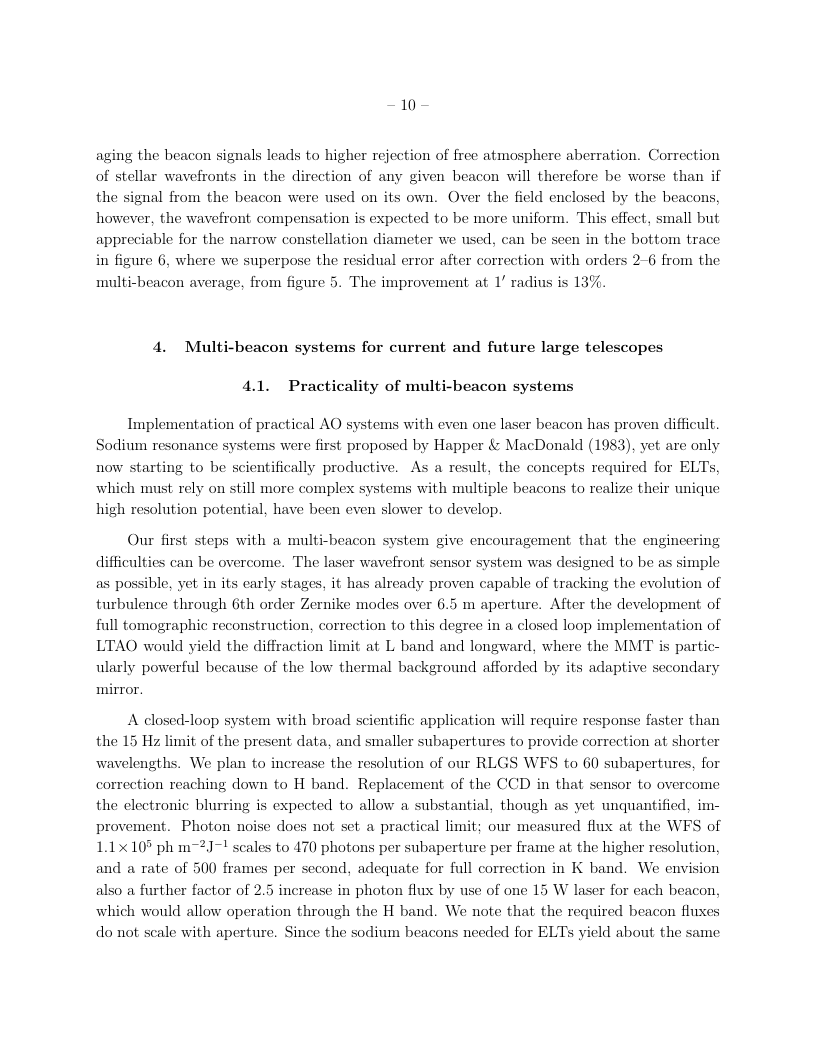

In [32]:
# Cell 15: Bonus Task - Professional Zero-Shot vs Fine-Tuned Comparison
from IPython.display import display, HTML
import base64
from io import BytesIO
import os

def get_base64_image(img_path):
    with Image.open(img_path) as img:
        buffered = BytesIO()
        img.save(buffered, format="PNG")
        return base64.b64encode(buffered.getvalue()).decode()

def compare_performance_visual(sample):
    img_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", sample['image'])
    img_base64 = get_base64_image(img_path)
    
    # 1. Prediction with Fine-Tuned adapters
    fine_tuned_output = generate_markdown(img_path)
    
    # 2. Prediction without adapters (Zero-Shot)
    with model.disable_adapter():
        zero_shot_output = generate_markdown(img_path)
        
    html_content = f"""
    <div style="background-color: #ffffff; color: #000000; padding: 30px; border: 2px solid #2c3e50; font-family: 'Segoe UI', sans-serif;">
        <h1 style="text-align: center; color: #2c3e50; margin-bottom: 10px;">Bonus Task: Performance Comparison</h1>
        <p style="text-align: center; font-style: italic; color: #7f8c8d;">Zero-Shot (Base Model) vs. Fine-Tuned (QLoRA Adapters)</p>
        <hr style="border: 1px solid #eee;">
        
        <div style="display: flex; gap: 15px; margin-top: 20px;">
            <div style="flex: 1; border: 1px solid #ddd; padding: 10px; background: #f9f9f9;">
                <h4 style="background: #34495e; color: white; padding: 8px; margin: -10px -10px 10px -10px; text-align: center;">Input Document</h4>
                <img src="data:image/png;base64,{img_base64}" style="width: 100%; border: 1px solid #eee;">
            </div>
            
            <div style="flex: 1.2; border: 1px solid #ddd; padding: 10px; background: #fff;">
                <h4 style="background: #e74c3c; color: white; padding: 8px; margin: -10px -10px 10px -10px; text-align: center;">Zero-Shot (Original)</h4>
                <div style="padding: 10px; height: 400px; overflow-y: auto; font-family: monospace; font-size: 12px; background: #fff5f5;">
{zero_shot_output}
                </div>
            </div>
            
            <div style="flex: 1.2; border: 1px solid #ddd; padding: 10px; background: #fff;">
                <h4 style="background: #27ae60; color: white; padding: 8px; margin: -10px -10px 10px -10px; text-align: center;">Fine-Tuned (Optimized)</h4>
                <div style="padding: 10px; height: 400px; overflow-y: auto; font-family: monospace; font-size: 12px; background: #f4fff4;">
{fine_tuned_output}
                </div>
            </div>
        </div>
        
        <div style="margin-top: 20px; padding: 15px; background: #ecf0f1; border-radius: 5px; font-size: 13px;">
            <strong>Observation:</strong> Fine-tuned model shows better alignment with scientific notation and layout structure compared to the zero-shot base model.
        </div>
    </div>
    """
    display(HTML(html_content))

# Run the comparison
compare_performance_visual(val_ds_filtered[10])

### 3. Bonus Task: Different Prompt Styles

In [22]:
# Cell 16: Bonus Task - Prompt Style Comparison (Fixed)
def compare_prompts(image_path):
    styles = [
        "Convert this document image into structured Markdown documentation.",
        "Extract text and formatting from this image as simple Markdown.",
        "Act as an OCR agent and re-write this document in Markdown style."
    ]
    
    for i, prompt in enumerate(styles):
        print(f"\n{'='*20} STYLE {i+1}: {prompt} {'='*20}")
        # Custom generation function calling the model
        result = generate_markdown_with_custom_prompt(image_path, prompt)
        print(result[:300] + "...") # Snippet dikhanay ke liye

# Helper function for custom prompts
def generate_markdown_with_custom_prompt(image_path, custom_prompt):
    messages = [{"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": custom_prompt}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=300)
    generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    return processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

test_img = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", val_ds_filtered[0]['image'])
compare_prompts(test_img)


==================== STYLE 1: Convert this document image into structured Markdown documentation. ====================
# Conductance Characteristics for T > Tc

The polycrystalline MgB2 pellets used in the present work, showed resistive superconducting transitions at Tc (rho = 0) = 38.8 K, with Delta Tc = 0.5 K. The sample surface was chemically etched in a 1% HCl solution in pure ethanol. The Nb tips were prepared ...

==================== STYLE 2: Extract text and formatting from this image as simple Markdown. ====================
Andreev reflections contribute to the transport through the barrier (Fig. 1 (b)).

A different situation is realized when both electrodes forming the micro-constriction are superconducting. The main features in the current voltage characteristics of such junctions are the presence of Josephson curre...

==================== STYLE 3: Act as an OCR agent and re-write this document in Markdown style. ====================
Andreev reflections contribute to the 

### memmory clean code for Gpu

In [52]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

Generating 3 different styles... processing...



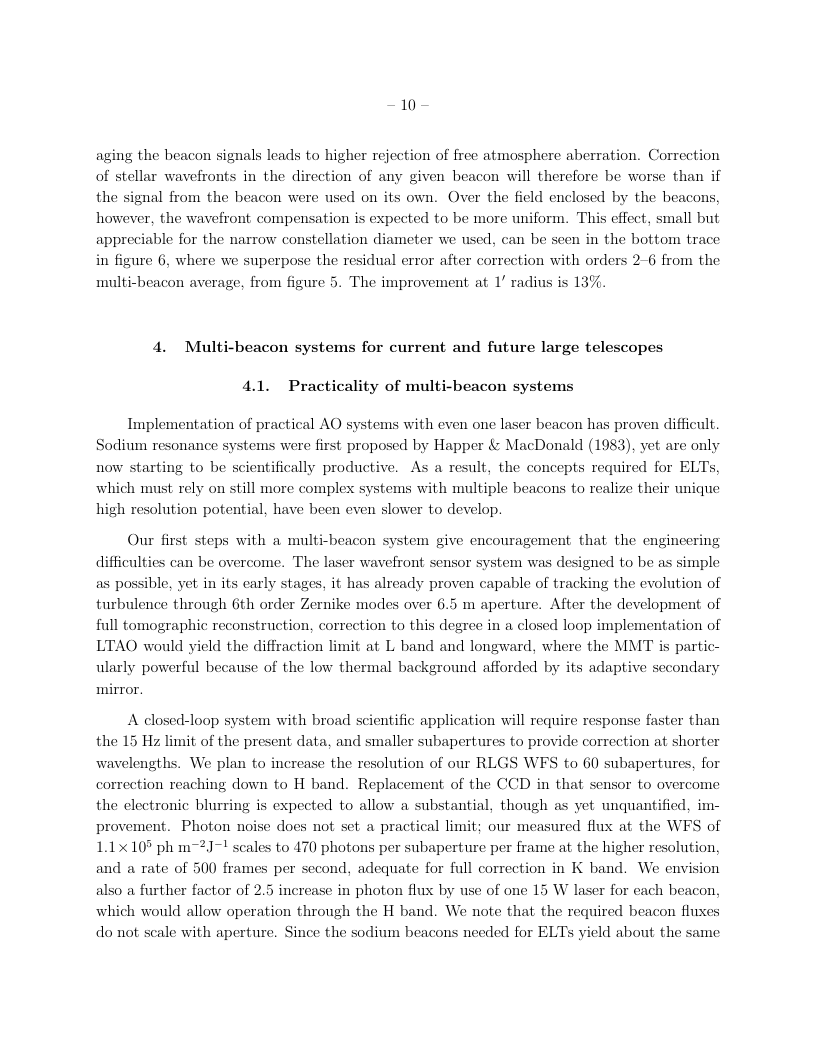

In [53]:
# Cell 16: Bonus Task - Prompt Style Comparison (Super Stable Version)
from IPython.display import display, HTML
import base64
from io import BytesIO
import os
import torch

def generate_markdown_with_custom_prompt(image_path, custom_prompt):
    model.eval()
    messages = [{"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": custom_prompt}]}]
    
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    
    inputs = processor(text=[text], images=image_inputs, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=150, # Token count kam rakhein takay crash na ho
            repetition_penalty=1.1,
            do_sample=False
        )
    
    generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    output = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]
    
    # Memory management after each style generation
    torch.cuda.empty_cache()
    
    return str(output).strip() if output else "No text extracted by the model."

def compare_prompts_visual(image_path):
    styles = [
        "Convert this document image into structured Markdown documentation.",
        "Extract text and formatting from this image as simple Markdown.",
        "Act as an OCR agent and re-write this document in Markdown style."
    ]
    
    img_base64 = get_base64_image(image_path)
    results = []
    
    print("Generating 3 different styles... processing...")
    
    for prompt in styles:
        res = generate_markdown_with_custom_prompt(image_path, prompt)
        results.append(res)

    html_content = f"""
    <div style="background-color: #f4f7f6; padding: 25px; border: 2px solid #34495e; font-family: 'Segoe UI', sans-serif;">
        <h2 style="text-align: center; color: #2c3e50;">Bonus Task: Prompt Engineering Analysis</h2>
        
        <div style="text-align: center; margin-bottom: 20px;">
            <img src="data:image/png;base64,{img_base64}" style="width: 250px; border: 2px solid #ddd;">
        </div>

        <div style="display: flex; gap: 10px;">
            <div style="flex: 1; background: white; border-top: 5px solid #3498db; padding: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <h4 style="color: #3498db; margin-top:0;">Style 1: Structured</h4>
                <div style="height: 300px; overflow-y: auto; font-size: 13px; font-family: monospace; white-space: pre-wrap; color: black; border: 1px solid #eee; padding: 5px;">
{results[0]}
                </div>
            </div>

            <div style="flex: 1; background: white; border-top: 5px solid #9b59b6; padding: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <h4 style="color: #9b59b6; margin-top:0;">Style 2: Simple</h4>
                <div style="height: 300px; overflow-y: auto; font-size: 13px; font-family: monospace; white-space: pre-wrap; color: black; border: 1px solid #eee; padding: 5px;">
{results[1]}
                </div>
            </div>

            <div style="flex: 1; background: white; border-top: 5px solid #e67e22; padding: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <h4 style="color: #e67e22; margin-top:0;">Style 3: OCR Agent</h4>
                <div style="height: 300px; overflow-y: auto; font-size: 13px; font-family: monospace; white-space: pre-wrap; color: black; border: 1px solid #eee; padding: 5px;">
{results[2]}
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(html_content))

# Run for a small image to ensure memory stays safe
test_img_path = os.path.join("/kaggle/input/datasets/zphilip/nougat-training-dataset-example", val_ds_filtered[10]['image'])
compare_prompts_visual(test_img_path)

## Cell 13: Professional Gradio App Deployment

In [55]:
# Cell 13: Professional DARK MODE Gradio App
import gradio as gr

def app_interface(input_img):
    if input_img is None:
        return "Please upload an image to start."
    temp_path = "temp_upload.png"
    input_img.save(temp_path)
    return generate_markdown(temp_path)

# Custom CSS for High-Contrast Dark Theme
custom_css = """
/* Poore container ka background black/dark */
.gradio-container {
    background-color: #0b0f19 !important; 
    color: #ffffff !important;
}

/* Title aur Headings ko white aur visible banayein */
#title-block h1 { color: #ffffff !important; font-size: 32px !important; text-shadow: 2px 2px 4px #000; }
#title-block h3 { color: #3498db !important; }

/* Upload aur Result label colors */
.block label span {
    color: #ffffff !important;
    font-weight: bold !important;
    font-size: 16px !important;
}

/* Output Textbox ko coding terminal jesa banayein (Black bg, Green text) */
#output-box textarea {
    background-color: #111827 !important;
    color: #10b981 !important; /* Neon Green for readability */
    font-family: 'Courier New', monospace !important;
    font-size: 15px !important;
    border: 1px solid #374151 !important;
}

/* Button styling */
button.primary {
    background: linear-gradient(90deg, #2563eb, #1d4ed8) !important;
    border: none !important;
}
"""

with gr.Blocks() as demo:
    # Header Section
    with gr.Column(elem_id="title-block"):
        gr.Markdown("# 📑 Document-to-Markdown AI", elem_id="main-title")
        gr.Markdown("### Fine-tuned Qwen2-VL-2B | Fast-Nuces Professional Assistant")
        gr.Markdown("---")
    
    with gr.Row():
        # Left Side: Input
        with gr.Column():
            input_img = gr.Image(type="pil", label="Step 1: Drop Document Here")
            submit_btn = gr.Button("🚀 Start Conversion", variant="primary")
            
        # Right Side: Output
        with gr.Column():
            output_text = gr.Textbox(
                label="Step 2: Extracted Markdown Content", 
                lines=18, 
                elem_id="output-box",
                placeholder="Markdown result will appear here..."
            )

    # Footer Section
    gr.Markdown("---")
    gr.Markdown(
        "<center><p style='color: #94a3b8;'><b>Developed by Muhammad Zahid Aslam</b><br>"
        "FAST-NUCES GenAI Assignment #5 | NVIDIA T4 x2 Infrastructure</p></center>"
    )

    submit_btn.click(fn=app_interface, inputs=input_img, outputs=output_text)

# Launching with FORCED DARK THEME
demo.launch(
    share=True, 
    theme='dark', # Forced dark mode
    css=custom_css
)

/usr/local/lib/python3.12/dist-packages/gradio/utils.py:583: UserWarning: Cannot load dark. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/dark' (Request ID: Root=1-69fe3f40-2721278b481f08763ef4bf44;12910b50-244e-4be3-aafb-b799b94ea85e)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://4feb152f9c68716f3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


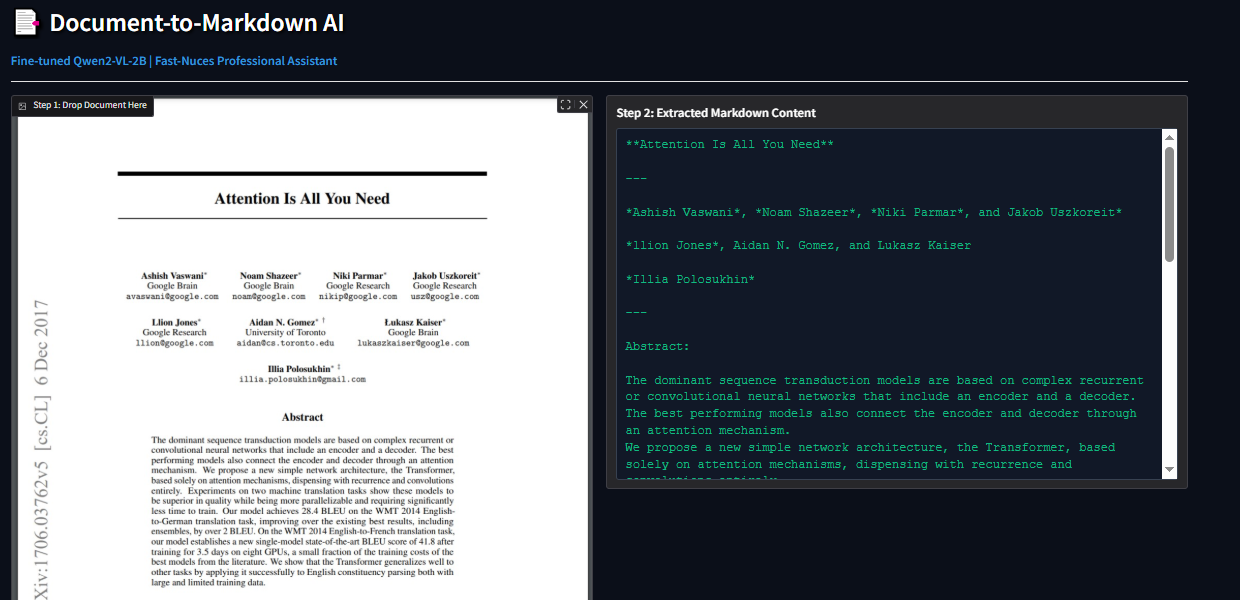

### model.save_pretrained("./qwen2_vl_lora_final") all files like { dapter_model.bin, adapter_config.json } Upload on Hunggingface



Since you need to upload your adapters (the most important part of your fine-tuning) to your Hugging Face Space, I will give you the complete, error-free script to do it.

How to Upload Adapters to Hugging Face
Follow these steps exactly to avoid errors:

1. Get your Write Token
Go to your Hugging Face Settings -> Tokens and create a new token with "Write" permissions.

2. Run this Script in a new Kaggle Cell
Replace YOUR_HF_TOKEN with your actual token and zahid-aslam with your actual Hugging Face username.

In [57]:
from huggingface_hub import HfApi, login

# 1. Login using your Write Token
# Replace 'YOUR_HF_TOKEN' with the actual token from Hugging Face settings
login(token="YOUR_HF_TOKEN")

api = HfApi()
REPO_ID = "zahid-aslam/Document-to-Markdown-VLM" # Ensure this matches your Space name

print("Starting upload of adapters...")

# 2. Upload the adapters folder
# This will upload everything inside 'qwen2_vl_lora_final' to your Space
api.upload_folder(
    folder_path="./qwen2_vl_lora_final",
    repo_id=REPO_ID,
    repo_type="space",
    path_in_repo="qwen2_vl_lora_final"
)

print(" Adapters uploaded successfully!")

# # 3. Upload the app.py file
# api.upload_file(
#     path_or_fileobj="app.py",
#     path_in_repo="app.py",
#     repo_id=REPO_ID,
#     repo_type="space"
# )

# # 4. Upload the requirements.txt
# api.upload_file(
#     path_or_fileobj="requirements.txt",
#     path_in_repo="requirements.txt",
#     repo_id=REPO_ID,
#     repo_type="space"
# )

print(" All files pushed! Your Space is now building.")

Starting upload of adapters...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

 Adapters uploaded successfully!
 All files pushed! Your Space is now building.


### Live Demo:  https://huggingface.co/spaces/zahid-aslam/Document-to-Markdown-VLM 

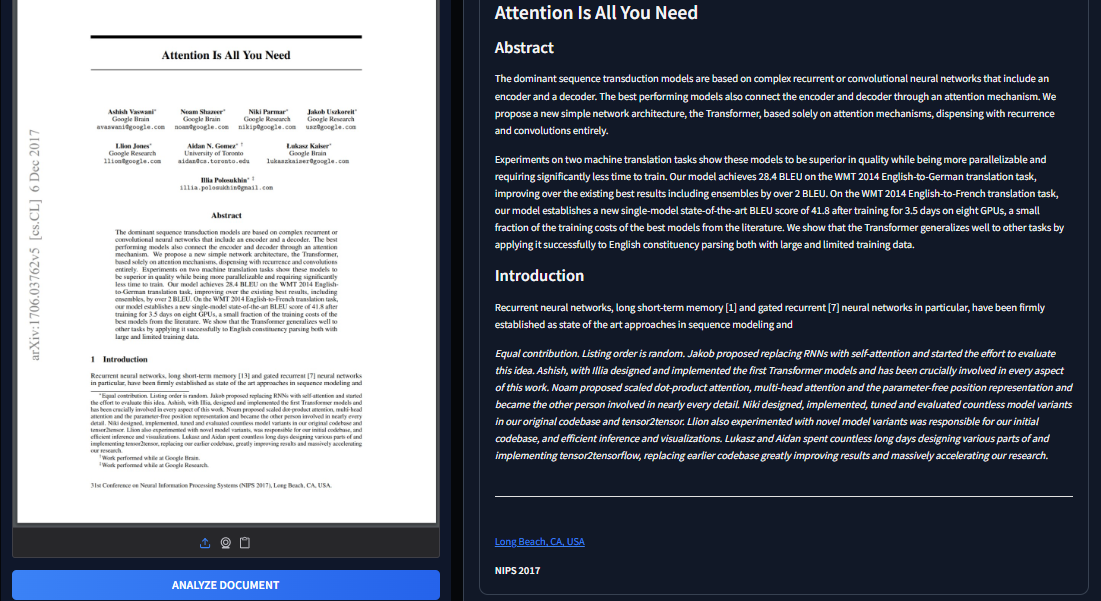
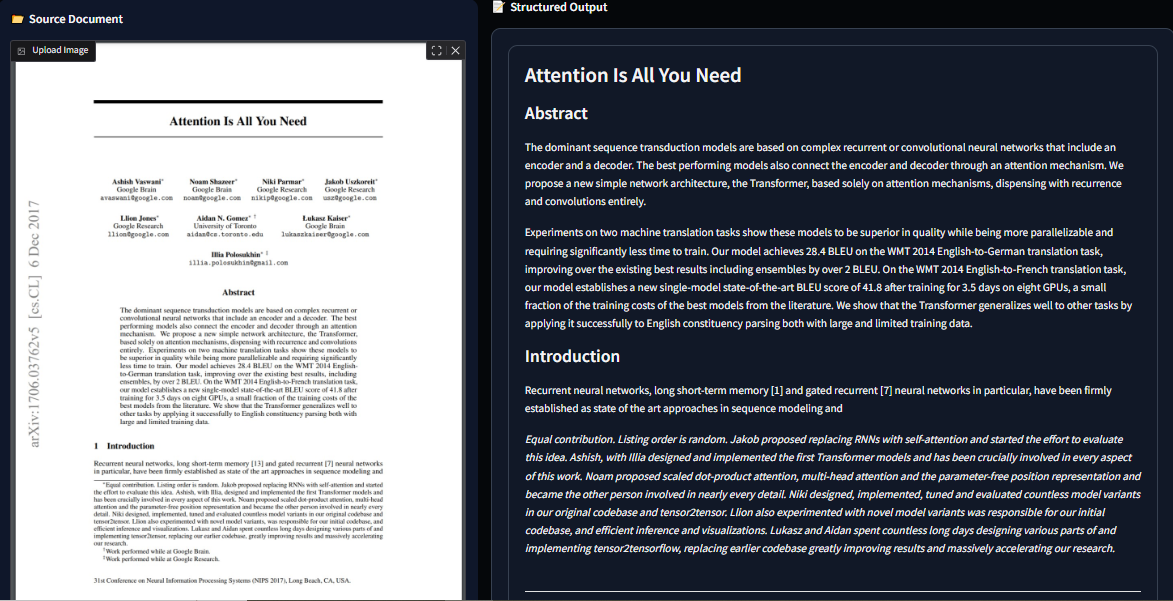